# Бинарная кластеризация KMeans: iPhone vs Android

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    confusion_matrix,
    classification_report,
    adjusted_rand_score,
    normalized_mutual_info_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)
from scipy.optimize import linear_sum_assignment

sns.set(style='whitegrid')
RANDOM_STATE = 42

1. Загрузка и переименование колонок

In [2]:
df = pd.read_csv('ИСИТ_1_практика_Ответы_на_форму_1.csv')

rename_map = {
    'Отметка времени': 'timestamp',
    'Как вы себя чувствуете, когда оказались в центре внимания в малознакомой компании?': 'attention_feel',
    'Как чаще всего принимаются ваши повседневные решения о покупках?': 'purchase_decisions',
    'Покупая сложную технику или мебель, какой подход вам ближе?': 'complex_tech_approach',
    'Что вы выберете при покупке повседневной вещи?': 'daily_item_choice',
    'Быстро ли твой телефон разряжается?': 'phone_battery_fast',
    'Ты часто снимаешь на телефон фото/видео?': 'phone_photo_video',
    'При выборе предмета интерьера или одежды, что станет решающим фактором?': 'interior_clothing_factor',
    'Часто ли твой телефон тормозит/лагает?': 'phone_lags',
    'Тебе важно, чтобы все приложения со временем работали одинаково?': 'apps_equal_importance',
    'Любите ли вы путешествовать?': 'travel_love',
    'Как часто ты меняешь смартфон на новый? Введите число лет (целое, например: 2)': 'smartphone_change_years',
    'Как часто вы играете в видеоигры? Введите примерное кол-во часов в неделю (целое, например: 5)': 'videogames_hours_week',
    'Часто ли вы публикуете фотографии или видео в социальных сетях?': 'social_media_post_freq',
    'Часто ли вы смотрите фильмы и сериалы на телефоне?': 'phone_movies_freq',
    'Цвет глаз? (С большой буквы в именительном падеже единственное число, например: Зеленый)': 'eye_color',
    'Ближайшая станция метро? (Точное название, например: Преображенская площадь, Сокольники и т.п.)': 'metro_station',
    'У тебя айфон или андроид?': 'target_os'
}

df = df.rename(columns=rename_map)
print(df.shape)
df.head()

(44, 18)


,timestamp,attention_feel,purchase_decisions,complex_tech_approach,daily_item_choice,phone_battery_fast,phone_photo_video,interior_clothing_factor,phone_lags,apps_equal_importance,travel_love,smartphone_change_years,videogames_hours_week,social_media_post_freq,phone_movies_freq,eye_color,metro_station,target_os
0,11.09.2026 20:01:26,Комфортно,Рационально,Чтобы всё сразу работало из коробки,Какой-то уникальный вариант,Да,Нет,"Дизайн, эстетика",Нет,Да,Да,4,5,Нет,Да,Зеленый,Юго-западная,Айфон
1,11.09.2026 20:01:27,Комфортно,Рационально,Чтобы всё сразу работало из коробки,Какой-то уникальный вариант,Да,Да,"Долговечность, польза",Нет,Да,Да,3,1,Да,Да,Карий,Бульвар Дмитрия Донского,Айфон
2,11.09.2026 20:01:38,Комфортно,Рационально,Чтобы всё сразу работало из коробки,Что-то популярное,Нет,Да,"Дизайн, эстетика",Нет,Да,Да,3,1,Нет,Нет,Карий,Братиславская,Айфон
3,11.09.2026 20:01:41,Дискомфортно,Рационально,Чтобы всё сразу работало из коробки,Какой-то уникальный вариант,Да,Нет,"Долговечность, польза",Нет,Да,Да,3,0,Нет,Нет,Серый,Авиамоторная,Айфон
4,11.09.2026 20:02:11,Комфортно,Рационально,Чтобы всё сразу работало из коробки,Что-то популярное,Да,Нет,"Долговечность, польза",Да,Да,Да,4,6,Нет,Нет,Зеленый,Волжская,Андроид


2. Очистка и подготовка целевой переменной

In [3]:
# Целевая переменная: Айфон = 1, Андроид = 0
df['target'] = df['target_os'].astype(str).str.strip().str.lower().map({
    'айфон': 1,
    'андроид': 0
})

# Удаляем служебные и слишком высококардинальные признаки
df = df.drop(columns=['timestamp', 'target_os', 'metro_station'])

# Удаляем строки без целевой переменной
df = df.dropna(subset=['target']).copy()

# Приводим категориальные признаки к нижнему регистру и убираем лишние пробелы
for col in df.select_dtypes(include='object').columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace('ё', 'е', regex=False)
    )

# Числовые признаки
for col in ['smartphone_change_years', 'videogames_hours_week']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df['target'].value_counts())
df.head()

target
0    28
1    16
Name: count, dtype: int64


,attention_feel,purchase_decisions,complex_tech_approach,daily_item_choice,phone_battery_fast,phone_photo_video,interior_clothing_factor,phone_lags,apps_equal_importance,travel_love,smartphone_change_years,videogames_hours_week,social_media_post_freq,phone_movies_freq,eye_color,target
0,комфортно,рационально,чтобы все сразу работало из коробки,какой-то уникальный вариант,да,нет,"дизайн, эстетика",нет,да,да,4,5,нет,да,зеленый,1
1,комфортно,рационально,чтобы все сразу работало из коробки,какой-то уникальный вариант,да,да,"долговечность, польза",нет,да,да,3,1,да,да,карий,1
2,комфортно,рационально,чтобы все сразу работало из коробки,что-то популярное,нет,да,"дизайн, эстетика",нет,да,да,3,1,нет,нет,карий,1
3,дискомфортно,рационально,чтобы все сразу работало из коробки,какой-то уникальный вариант,да,нет,"долговечность, польза",нет,да,да,3,0,нет,нет,серый,1
4,комфортно,рационально,чтобы все сразу работало из коробки,что-то популярное,да,нет,"долговечность, польза",да,да,да,4,6,нет,нет,зеленый,0


3. Признаки и предобработка

In [4]:
X = df.drop(columns=['target'])
y = df['target'].astype(int)

num_cols = ['smartphone_change_years', 'videogames_hours_week']
cat_cols = [c for c in X.columns if c not in num_cols]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

X_prep = preprocessor.fit_transform(X)
print('Размер матрицы признаков:', X_prep.shape)

Размер матрицы признаков: (44, 39)


4. Подбор оптимального k: локоть и силуэт


Лучшее k по силуэту: 2
Значение силуэта: 0.504


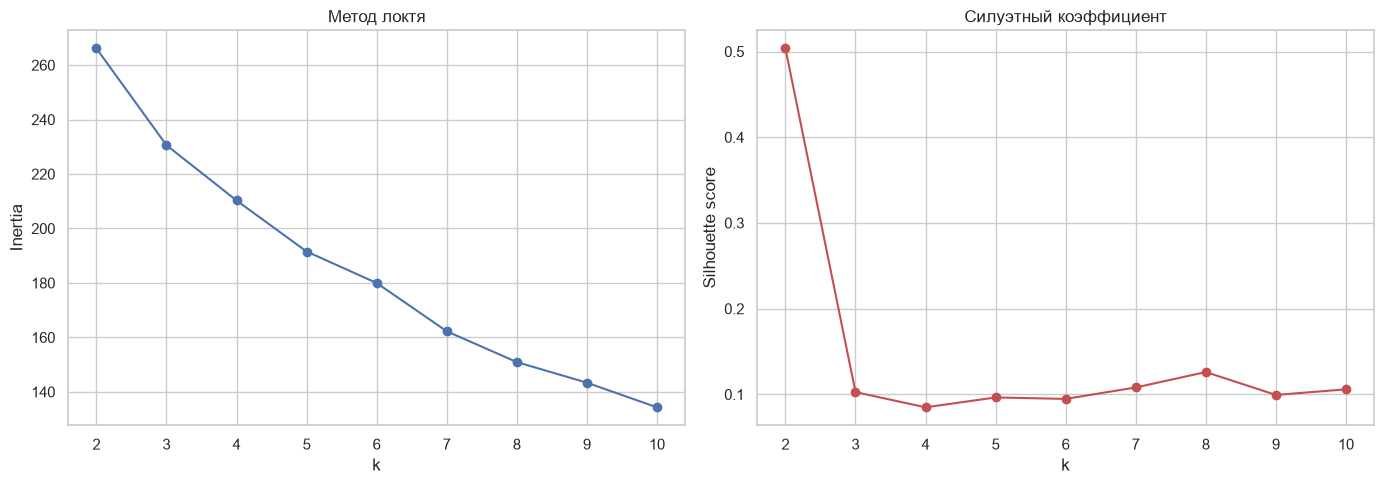

In [5]:
k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_prep)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_prep, labels))

best_k_sil = list(k_range)[int(np.argmax(sil_scores))]
print(f'Лучшее k по силуэту: {best_k_sil}')
print(f'Значение силуэта: {max(sil_scores):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Метод локтя')
axes[0].grid(True)

axes[1].plot(k_range, sil_scores, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Силуэтный коэффициент')
axes[1].grid(True)

plt.tight_layout()
plt.show()

5. KMeans с k=2 и сопоставление кластеров с классами


In [6]:
# Для бинарной задачи фиксируем k=2
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_prep)

# Сопоставляем кластеры с истинными классами через венгерский алгоритм
cm_raw = confusion_matrix(y, clusters)
row_ind, col_ind = linear_sum_assignment(-cm_raw)
mapping = {col: row for row, col in zip(row_ind, col_ind)}
y_pred = np.array([mapping[c] for c in clusters])

print('Сопоставление кластер -> класс:', mapping)
print('\nМатрица ошибок:')
print(confusion_matrix(y, y_pred))
print('\nОтчёт классификации:')
print(classification_report(y, y_pred, target_names=['Андроид', 'Айфон']))
print('Adjusted Rand Index:', adjusted_rand_score(y, clusters))
print('Normalized Mutual Information:', normalized_mutual_info_score(y, clusters))

Сопоставление кластер -> класс: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

Матрица ошибок:
[[27  1]
 [16  0]]

Отчёт классификации:
              precision    recall  f1-score   support

     Андроид       0.63      0.96      0.76        28
       Айфон       0.00      0.00      0.00        16

    accuracy                           0.61        44
   macro avg       0.31      0.48      0.38        44
weighted avg       0.40      0.61      0.48        44

Adjusted Rand Index: -0.019382192610539067
Normalized Mutual Information: 0.027286777815471574


6. Матрица ошибок


<Figure size 600x500 with 0 Axes>

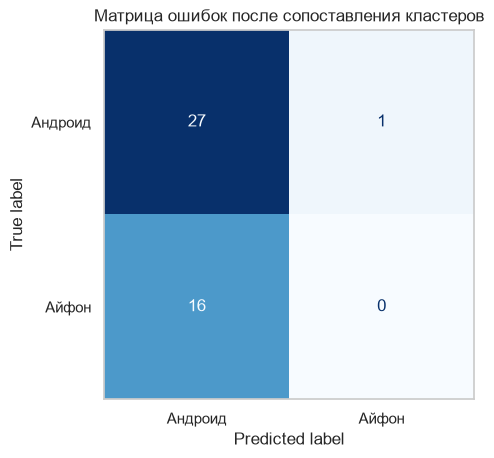

In [7]:
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred,
    display_labels=['Андроид', 'Айфон'],
    cmap='Blues',
    colorbar=False
)
plt.title('Матрица ошибок после сопоставления кластеров')
plt.grid(False)
plt.show()

7. Визуализация через PCA


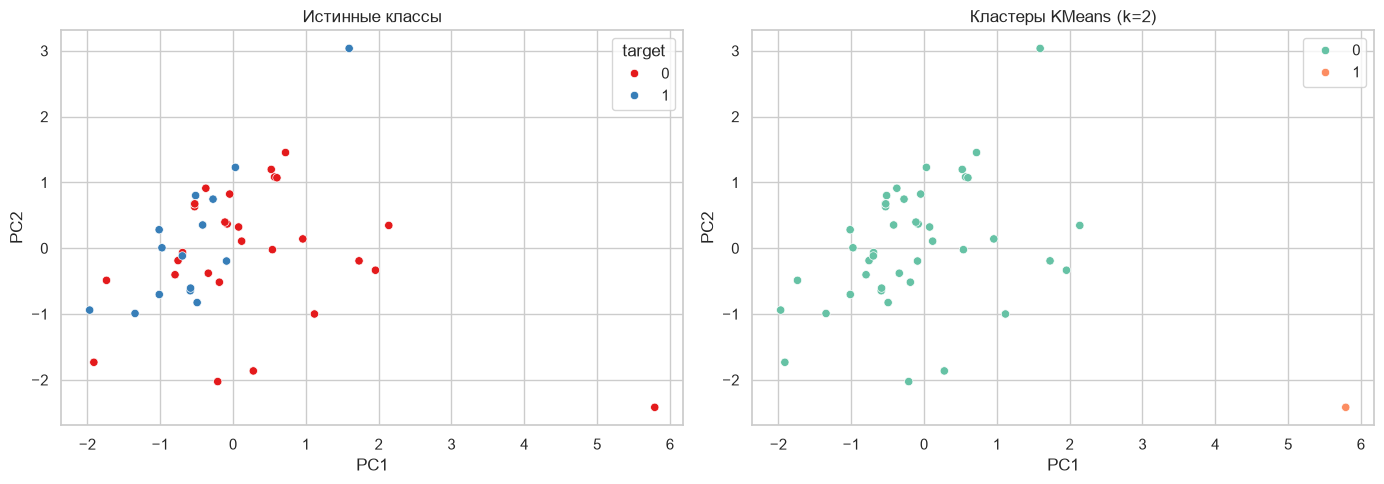

In [8]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_prep)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=y, palette='Set1', ax=axes[0]
)
axes[0].set_title('Истинные классы')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=clusters, palette='Set2', ax=axes[1]
)
axes[1].set_title('Кластеры KMeans (k=2)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

8. ROC-кривая для KMeans

> В KMeans нет вероятностей, но можно использовать разность расстояний до центроидов как скор.




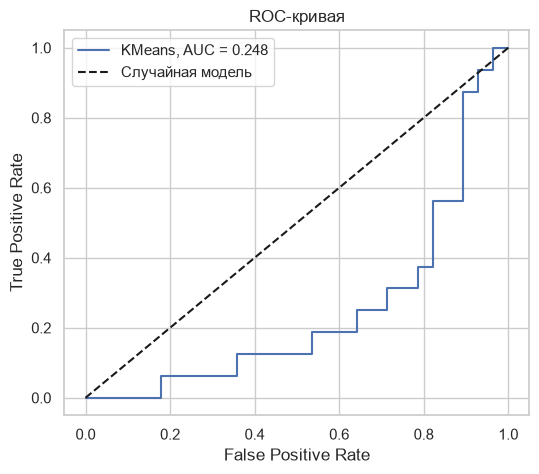

In [9]:
dist = kmeans.transform(X_prep)

cluster_for_1 = [c for c, lbl in mapping.items() if lbl == 1][0]
cluster_for_0 = [c for c, lbl in mapping.items() if lbl == 0][0]

# Чем ближе к кластеру класса 1 и дальше от класса 0, тем выше скор
score = dist[:, cluster_for_0] - dist[:, cluster_for_1]

fpr, tpr, _ = roc_curve(y, score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'KMeans, AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.grid(True)
plt.show()

9. Итоговые выводы

In [10]:
final_inertia = kmeans.inertia_
final_sil = silhouette_score(X_prep, clusters)

print('ИТОГИ:')
print(f'k = 2')
print(f'Inertia: {final_inertia:.3f}')
print(f'Silhouette: {final_sil:.3f}')
print(f'ARI: {adjusted_rand_score(y, clusters):.3f}')
print(f'NMI: {normalized_mutual_info_score(y, clusters):.3f}')

ИТОГИ:
k = 2
Inertia: 266.123
Silhouette: 0.504
ARI: -0.019
NMI: 0.027
